In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [166]:
# parse date is important for time series analysis, so we specify it here
df = pd.read_csv("layoffs.csv", parse_dates=['date'])     
df.head(10)

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Indeed + Glassdoor,Austin,1300.0,2025-07-10,NaN,HR,https://www.bloomberg.com/news/articles/2025-0...,Acquired,$5,United States,7/10/2025
1,Eigen Labs,Seattle,29.0,2025-07-08,25%,Crypto,https://blockworks.co/news/eigen-layoffs-25-ei...,Unknown,$234,United States,7/11/2025
2,Subtl AI,"Hyderabad,Non-U.S.",NaN,2025-07-03,100%,AI,https://inc42.com/buzz/genai-startup-subtl-ai-...,Seed,NaN,India,7/7/2025
3,Microsoft,Seattle,9000.0,2025-07-02,4%,Other,https://www.cnbc.com/2025/07/02/microsoft-layi...,Post-IPO,$1,United States,7/2/2025
4,Okra,"Lagos,Non-U.S.",NaN,2025-07-02,100%,Finance,https://techpoint.africa/news/okra-cofounder-f...,Series A,$12,Nigeria,7/7/2025
5,TikTok,"Dublin,Non-U.S.",NaN,2025-07-02,NaN,Consumer,https://www.bloomberg.com/news/articles/2025-0...,Acquired,NaN,United States,7/2/2025
6,TomTom,"Amsterdam,Non-U.S.",300.0,2025-06-30,10%,Other,https://www.tomtom.com/newsroom/press-releases...,Post-IPO,$430,Netherlands,7/7/2025
7,Rivian,Los Angeles,140.0,2025-06-26,1%,Transportation,https://techcrunch.com/2025/06/26/rivian-cuts-...,Post-IPO,$10700,United States,6/27/2025
8,Bumble,Austin,240.0,2025-06-25,30%,Consumer,https://www.cnbc.com/2025/06/25/bumble-layoffs...,Post-IPO,$313,United States,6/25/2025
9,Klue,"Vancouver,Non-U.S.",85.0,2025-06-25,40%,Sales,https://betakit.com/klue-lays-off-40-percent-o...,Series B,$83,United States,6/25/2025


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4100 entries, 0 to 4099
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company              4100 non-null   object        
 1   location             4099 non-null   object        
 2   total_laid_off       2676 non-null   float64       
 3   date                 4100 non-null   datetime64[ns]
 4   percentage_laid_off  2610 non-null   object        
 5   industry             4099 non-null   object        
 6   source               4097 non-null   object        
 7   stage                4093 non-null   object        
 8   funds_raised         3650 non-null   object        
 9   country              4100 non-null   object        
 10  date_added           4100 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 352.5+ KB


In [168]:
df = df.drop(columns=['source','date_added'])
df = df.dropna(subset=['total_laid_off'])
df['total_laid_off'] = pd.to_numeric(df['total_laid_off'], errors='coerce')
df = df.dropna(subset=['total_laid_off'])  # Redrop if coercion fails
df.describe()

,total_laid_off,date
count,2676.000000,2676
mean,281.640135,2022-10-22 05:44:55.964125440
min,3.000000,2020-03-11 00:00:00
25%,40.000000,2022-06-10 00:00:00
50%,85.000000,2023-01-05 00:00:00
75%,200.000000,2023-08-23 00:00:00
max,22000.000000,2025-07-10 00:00:00
std,973.996040,NaN


In [169]:
dfi = df[df['country'] == 'India']
dfi = dfi.drop(columns=['country'])
dfi.head(10)

,company,location,total_laid_off,date,percentage_laid_off,industry,stage,funds_raised
24,Cars24,"Gurugram,Non-U.S.",120.0,2025-05-27,NaN,Transportation,Series G,$1300
26,Otipy,"New Delhi,Non-U.S.",300.0,2025-05-23,100%,Food,Series B,$44
32,VerSe Innovation copy,"Bengaluru,Non-U.S.",350.0,2025-05-18,NaN,Media,Series J,$1700
41,GenWise,"New Delhi,Non-U.S.",15.0,2025-05-05,20%,Other,Seed,$3
53,Cars24,"Gurugram,Non-U.S.",200.0,2025-04-26,NaN,Transportation,Series G,$1300
57,Zopper,"Noida,Non-U.S.",100.0,2025-04-17,NaN,Finance,Series D,$125
61,GupShup,SF Bay Area,200.0,2025-04-15,NaN,Other,Series F,$484
91,Ola Electric,"Bengaluru,Non-U.S.",1000.0,2025-03-03,NaN,Transportation,Post-IPO,$1700
151,Pocket FM,"Bengaluru,Non-U.S.",75.0,2025-01-16,NaN,Media,Series D,$212
155,ShareChat,"Bengaluru,Non-U.S.",27.0,2025-01-15,5%,Marketing,Series D,$222


In [170]:
dfi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 235 entries, 24 to 4085
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company              235 non-null    object        
 1   location             235 non-null    object        
 2   total_laid_off       235 non-null    float64       
 3   date                 235 non-null    datetime64[ns]
 4   percentage_laid_off  127 non-null    object        
 5   industry             235 non-null    object        
 6   stage                234 non-null    object        
 7   funds_raised         217 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 16.5+ KB


In [171]:
dfi.shape

(235, 8)

In [172]:
dfi['date'].dtype 

dtype('<M8[ns]')

In [173]:
dfi['date'] = pd.to_datetime(dfi['date'], errors='coerce')
dfi = dfi.dropna(subset=['date'])
dfi['year'] = dfi['date'].dt.year
dfi['month'] = dfi['date'].dt.month


In [174]:
dfi['company'].nunique()

168

In [175]:
dfi['industry'].nunique()

21

In [176]:
dfi['location'].nunique()

15

In [177]:
dfi['stage'].nunique()

16

In [178]:
dfi.isnull().sum()

company                  0
location                 0
total_laid_off           0
date                     0
percentage_laid_off    108
industry                 0
stage                    1
funds_raised            18
year                     0
month                    0
dtype: int64

In [179]:
dfi['location'] = dfi['location'].str.replace(',Non-U.S.','')

dfi['funds_raised'] = dfi['funds_raised'].str.replace('$','')
dfi['funds_raised'] = pd.to_numeric(dfi['funds_raised'], errors='coerce')

dfi['percentage_laid_off'] = dfi['percentage_laid_off'].str.replace('%','')
dfi['percentage_laid_off'] = pd.to_numeric(dfi['percentage_laid_off'], errors='coerce')

dfi['percentage_laid_off'] = dfi['percentage_laid_off'].fillna(dfi['percentage_laid_off'].median())
dfi['funds_raised'] = dfi['funds_raised'].fillna(dfi['funds_raised'].median())

dfi.head(10)

,company,location,total_laid_off,date,percentage_laid_off,industry,stage,funds_raised,year,month
24,Cars24,Gurugram,120.0,2025-05-27,20.0,Transportation,Series G,1300.0,2025,5
26,Otipy,New Delhi,300.0,2025-05-23,100.0,Food,Series B,44.0,2025,5
32,VerSe Innovation copy,Bengaluru,350.0,2025-05-18,20.0,Media,Series J,1700.0,2025,5
41,GenWise,New Delhi,15.0,2025-05-05,20.0,Other,Seed,3.0,2025,5
53,Cars24,Gurugram,200.0,2025-04-26,20.0,Transportation,Series G,1300.0,2025,4
57,Zopper,Noida,100.0,2025-04-17,20.0,Finance,Series D,125.0,2025,4
61,GupShup,SF Bay Area,200.0,2025-04-15,20.0,Other,Series F,484.0,2025,4
91,Ola Electric,Bengaluru,1000.0,2025-03-03,20.0,Transportation,Post-IPO,1700.0,2025,3
151,Pocket FM,Bengaluru,75.0,2025-01-16,20.0,Media,Series D,212.0,2025,1
155,ShareChat,Bengaluru,27.0,2025-01-15,5.0,Marketing,Series D,222.0,2025,1


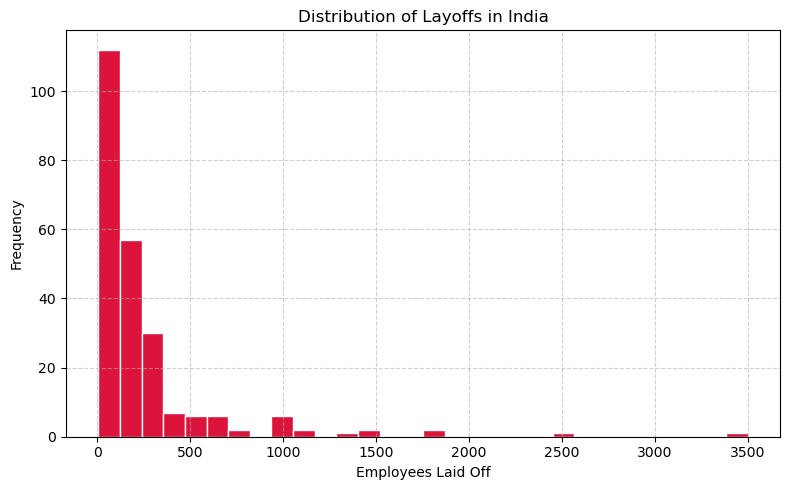

In [180]:
plt.figure(figsize=(8,5))
plt.hist(dfi['total_laid_off'], bins=30, color='crimson', edgecolor='white')
plt.title("Distribution of Layoffs in India")
plt.xlabel("Employees Laid Off")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [181]:
dfi.groupby('industry')['total_laid_off'].sum().sort_values(ascending=False).head(19)

industry
Education         14274.0
Finance            9156.0
Food               7515.0
Transportation     7070.0
Retail             6047.0
Consumer           3798.0
Travel             2500.0
Healthcare         2057.0
Other              1390.0
Fitness            1320.0
Media              1053.0
Marketing           718.0
Logistics           680.0
Real Estate         350.0
Crypto              284.0
Support             257.0
Data                217.0
Recruiting          200.0
Construction        140.0
Name: total_laid_off, dtype: float64

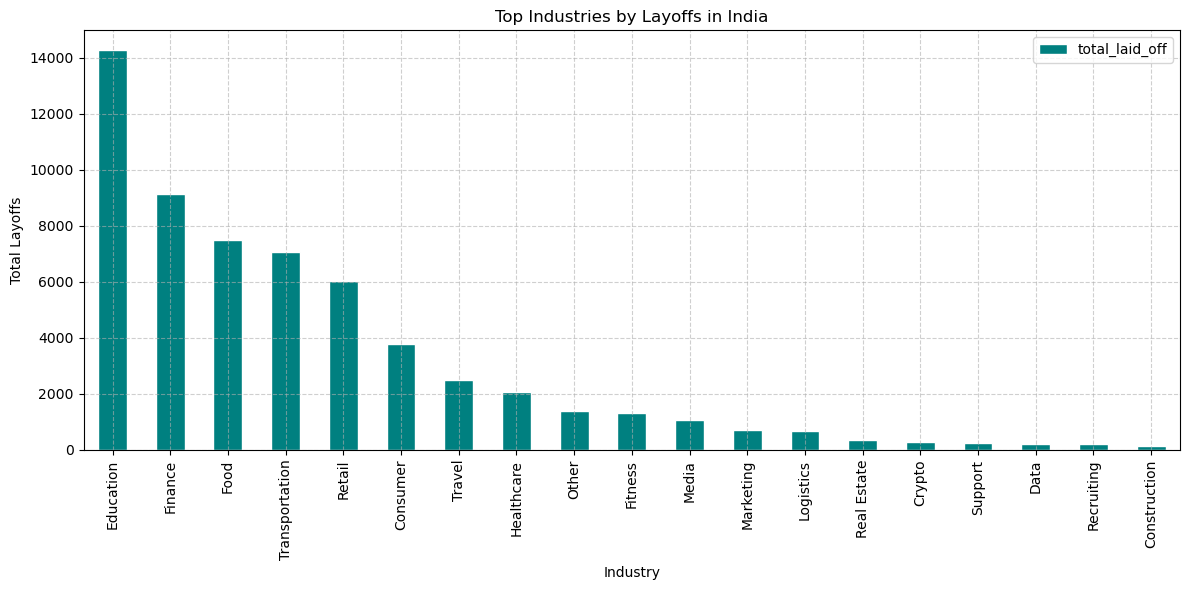

In [182]:
industry_layoffs = dfi.groupby('industry')['total_laid_off'].sum().sort_values(ascending=False).head(19)
plt.figure(figsize=(12,6))
industry_layoffs.plot(kind='bar', color='teal', edgecolor='white')
plt.title("Top Industries by Layoffs in India")
plt.xlabel("Industry")
plt.ylabel("Total Layoffs")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()

In [183]:
dfi.groupby('company')['total_laid_off'].sum().sort_values(ascending=False).head(20)

company
Byju's              5500.0
Paytm               5000.0
Swiggy              3280.0
Ola                 2980.0
WhiteHat Jr         2100.0
Bytedance           1800.0
Unacademy           1750.0
Ola Electric        1500.0
PaisaBazaar         1500.0
OYO                 1200.0
Vedantu             1109.0
Flipkart            1100.0
Reliance JioMart    1000.0
ShareChat            958.0
Curefit              920.0
Cars24               920.0
Meesho               901.0
MakeMyTrip           700.0
Udaan                630.0
Zomato               620.0
Name: total_laid_off, dtype: float64

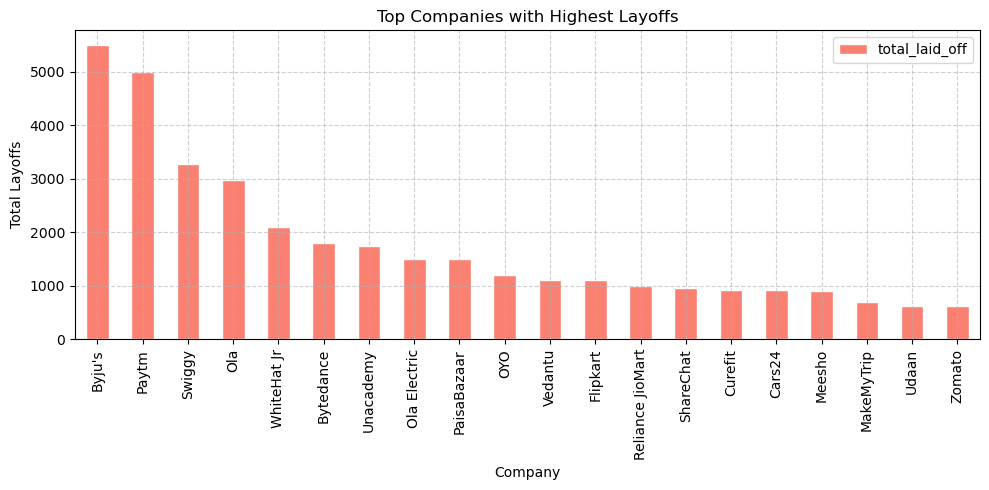

In [184]:
top_companies = dfi.groupby('company')['total_laid_off'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10,5))
top_companies.plot(kind='bar', color='salmon', edgecolor='white')
plt.title("Top Companies with Highest Layoffs")
plt.xlabel("Company")
plt.ylabel("Total Layoffs")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()

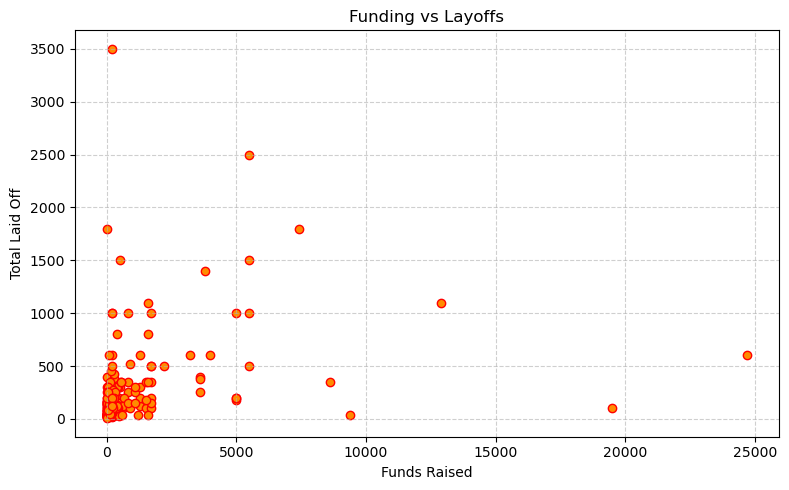

In [185]:
plt.figure(figsize=(8,5))
plt.scatter(dfi['funds_raised'], dfi['total_laid_off'], color='darkorange', edgecolors='red')
plt.title("Funding vs Layoffs")
plt.xlabel("Funds Raised")
plt.ylabel("Total Laid Off")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

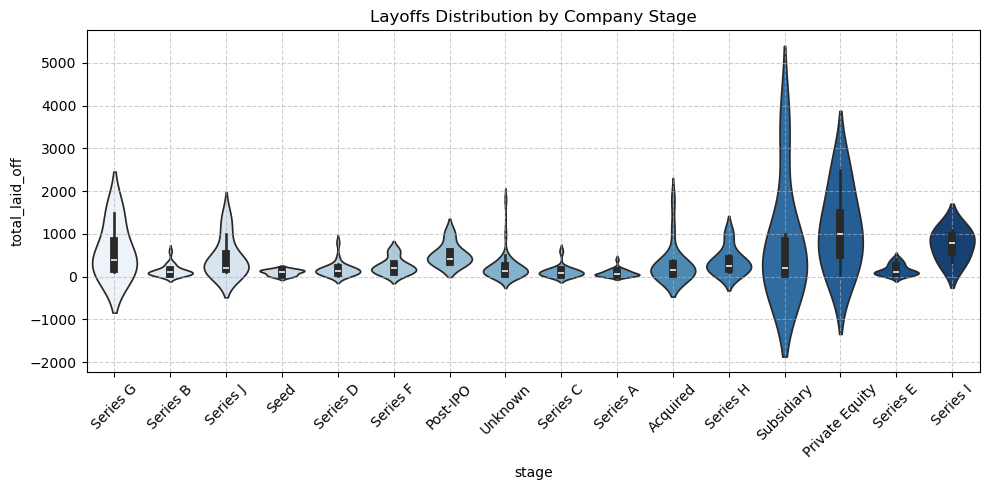

In [186]:
plt.figure(figsize=(10,5))
sns.violinplot(x='stage', y='total_laid_off', data=dfi, palette='Blues')
plt.xticks(rotation=45)
plt.title("Layoffs Distribution by Company Stage")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

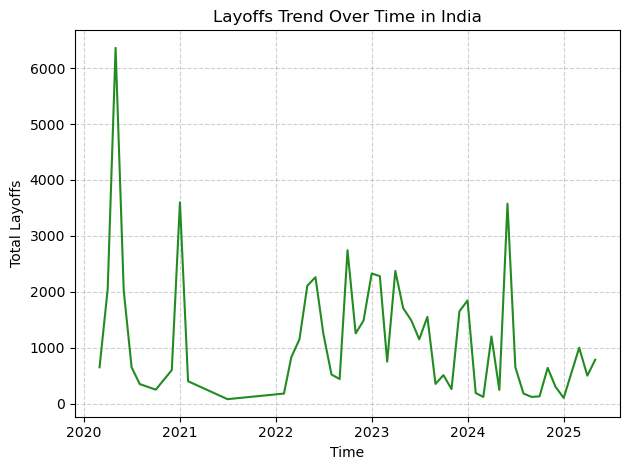

In [187]:
layoffs_time = dfi.groupby(['year','month'])['total_laid_off'].sum().reset_index()
layoffs_time['date'] = pd.to_datetime(layoffs_time[['year','month']].assign(day=1))
plt.plot(layoffs_time['date'], layoffs_time['total_laid_off'], color='forestgreen')
#layoffs_time.plot(figsize=(10,5), color='forestgreen')
plt.title("Layoffs Trend Over Time in India")
plt.xlabel("Time")
plt.ylabel("Total Layoffs")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

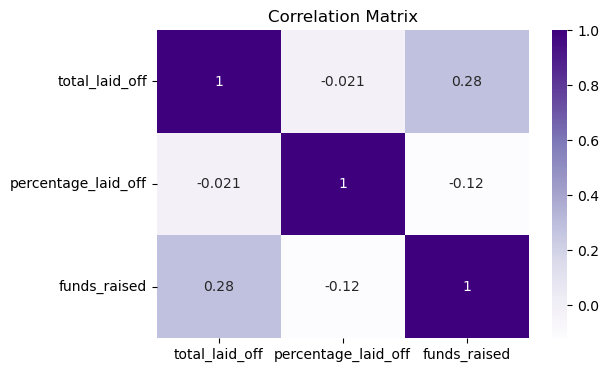

In [188]:
corr = dfi[['total_laid_off','percentage_laid_off','funds_raised']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Purples')
plt.title("Correlation Matrix")
plt.show()

In [189]:
dfi = dfi.drop(columns=['date'])
dfi = dfi.drop(columns=['company'])
dfi = pd.get_dummies(dfi, columns=['location','industry','stage'], drop_first=True)
dfi.head(10)

,total_laid_off,percentage_laid_off,funds_raised,year,month,location_Bengaluru,location_Chennai,location_Gurugram,location_Indore,location_Kolkata,...,stage_Series C,stage_Series D,stage_Series E,stage_Series F,stage_Series G,stage_Series H,stage_Series I,stage_Series J,stage_Subsidiary,stage_Unknown
24,120.0,20.0,1300.0,2025,5,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
26,300.0,100.0,44.0,2025,5,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
32,350.0,20.0,1700.0,2025,5,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
41,15.0,20.0,3.0,2025,5,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
53,200.0,20.0,1300.0,2025,4,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
57,100.0,20.0,125.0,2025,4,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
61,200.0,20.0,484.0,2025,4,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
91,1000.0,20.0,1700.0,2025,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
151,75.0,20.0,212.0,2025,1,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
155,27.0,5.0,222.0,2025,1,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [190]:
dfi.shape

(235, 51)

In [191]:
dfi.describe()

,total_laid_off,percentage_laid_off,funds_raised,year,month
count,235.000000,235.000000,235.000000,235.000000,235.000000
mean,251.982979,22.689362,927.123404,2022.468085,5.689362
std,392.797462,16.358474,2566.076748,1.334151,3.171941
min,6.000000,1.000000,1.000000,2020.000000,1.000000
25%,60.000000,20.000000,58.000000,2022.000000,3.500000
50%,130.000000,20.000000,190.000000,2023.000000,5.000000
75%,260.500000,20.000000,493.000000,2023.000000,8.000000
max,3500.000000,100.000000,24700.000000,2025.000000,12.000000


In [192]:

Q1 = dfi['total_laid_off'].quantile(0.25)
Q3 = dfi['total_laid_off'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

dt = dfi[(dfi['total_laid_off'] >= lower) & (dfi['total_laid_off'] <= upper)]

print("After Outlier Removal:", dfi.shape)

After Outlier Removal: (235, 51)


In [193]:
dfi['funding_per_layoff'] = dfi['funds_raised'] / (dfi['percentage_laid_off'] + 1)

In [194]:
#model training
from sklearn.model_selection import train_test_split

# train-80 and test-20
x = dfi.drop(columns=['total_laid_off'])
y = dfi['total_laid_off']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [195]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
#model training
lr_model.fit(x_train, y_train)

LinearRegression()

In [196]:
from sklearn.metrics import mean_squared_error, r2_score

predictions = lr_model.predict(x_test)

print("R2 Score:", r2_score(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))

R2 Score: -0.1935741541008713
MSE: 151573.6935734617


In [197]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=0.5)
ridge.fit(x_train, y_train)
print("Ridge R2:", ridge.score(x_test, y_test))

Ridge R2: -0.11320637974348302


In [198]:
lasso = Lasso(alpha=0.2, max_iter=2000)
lasso.fit(x_train, y_train)
print("Lasso R2:", lasso.score(x_test, y_test))

Lasso R2: -0.13085879986669302


In [199]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(x_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [200]:

rf_predictions = rf_model.predict(x_test)
from sklearn.metrics import r2_score, mean_squared_error

print("Random Forest R2:", r2_score(y_test, rf_predictions))
print("Random Forest MSE:", mean_squared_error(y_test, rf_predictions))


Random Forest R2: 0.18146217843220813
Random Forest MSE: 103947.29185307077


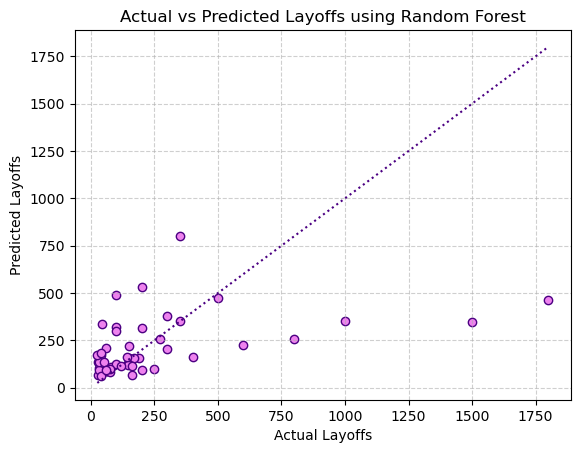

In [201]:
plt.scatter(y_test, rf_predictions, color='violet', edgecolors='indigo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='indigo', linestyle=':')
plt.xlabel("Actual Layoffs")
plt.ylabel("Predicted Layoffs")
plt.title("Actual vs Predicted Layoffs using Random Forest")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [202]:
importances = rf_model.feature_importances_
features = x.columns
importance_df = pd.DataFrame({'feature':features, 'importance':importances}).sort_values(by='importance', ascending=False)

print(importance_df.head(10))

                 feature  importance
1           funds_raised    0.165045
48      stage_Subsidiary    0.148965
3                  month    0.123646
2                   year    0.095071
36  stage_Private Equity    0.089053
50    funding_per_layoff    0.084401
12        location_Noida    0.080563
0    percentage_laid_off    0.042980
18    industry_Education    0.033942
20      industry_Finance    0.029144


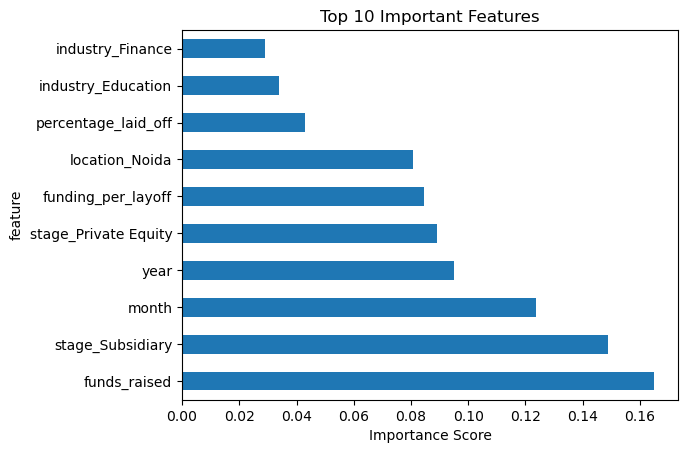

In [203]:
# Plot top 10 important features
importance_df.set_index('feature')['importance'].nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

In [204]:
from sklearn.preprocessing import PolynomialFeatures

X_poly = dfi[['percentage_laid_off', 'funds_raised', 'month', 'year']]
y = dfi['total_laid_off']

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_poly)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_reg = LinearRegression()
poly_reg.fit(X_train, y_train)

pred = poly_reg.predict(X_test)
print("Polynomial R2:", r2_score(y_test, pred))

Polynomial R2: 0.3422107347117713


In [205]:
# Predicting the charges
y_test_pred = poly_reg.predict(X_test)

# Comparing actual vs predicted values
dfi = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

dfi.head()

,Actual,Predicted
1170,300.0,215.320440
3570,1500.0,309.138426
3288,145.0,185.243899
155,27.0,73.717338
2088,200.0,439.208096
